# OpenPIVwGS

This notebook integrates the segmentation workflow described in the

## Flow Segmentation Setup

The required dependencies for optical flow processing and segmentation-based masking are imported, including OpenPIV for PIV computation and a custom flow segmentation module. GPU memory is cleared to ensure stable execution for subsequent processing steps.

In [1]:


#@title Import the needed libraries
#@markdown Run this block to import the dependencies.
import pkg_resources
import os
from glob import glob
import cv2
import time
import matplotlib.pyplot as plt
%matplotlib inline
from openpiv_cpu.cpu_process import piv_cpu

from Scripts.FlowSeg import FlowSeg
import numpy as np

import torch

torch.cuda.empty_cache()

/tmp/ipykernel_27531/3409054365.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## PIV Frame Pair Visualization

Two sequential PIV frames are loaded and displayed side-by-side in grayscale for comparison. Axis ticks are standardized to provide spatial reference and help visualize particle displacement across the image domain.

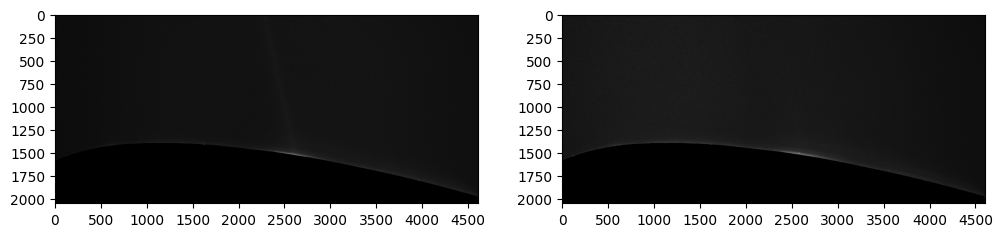

In [2]:
Name1="Frame_00000.tif" #Change name for PIV image used to generate mask
Name2="Frame_00001.tif" #Change name for PIV image used to generate mask
InputPath=os.path.join(os.getcwd(),"input")
GenPath1=os.path.join(os.getcwd(),"input",Name1)
GenPath2=os.path.join(os.getcwd(),"input",Name2)
OutPath=os.path.join(os.getcwd(), "Temp.png")

frame_a  = cv2.imread(GenPath1, cv2.IMREAD_ANYDEPTH)
frame_b  = cv2.imread(GenPath2, cv2.IMREAD_ANYDEPTH)

fig, axs = plt.subplots(1, 2, figsize=(12,10))
axs[0].imshow(frame_a, cmap=plt.cm.gray)
axs[1].imshow(frame_b, cmap=plt.cm.gray)

# Modify tick labels and ticks.
tick_step = 250
ht, wd = frame_a.shape
for ax in axs:
    ax.set_xticks(range(0, wd, 2 * tick_step))
    ax.set_yticks(range(0, ht, tick_step))

plt.show()

## FlowSeg Mask Generation and Visualization

A segmentation mask is generated using a text-prompt-based flow segmentation model to isolate the target structure in the image. The binary mask is converted into a displayable format and overlaid onto the original image using cv2, highlighting the detected region while preserving background context.

final text_encoder_type: bert-base-uncased
Check the latest .pth from: https://github.com/IDEA-Research/GroundingDINO/releases
Height: 2052
Width: 4603
X: 2300
Y: 1716
Mask shape: (1, 2652, 5203)
(2652, 5203)
(2652, 5203)
(2052, 4603)


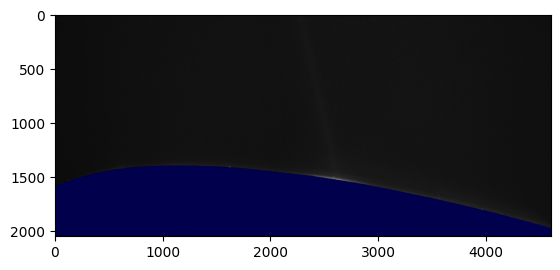

In [3]:
MaskOut=FlowSeg(GenPath1,"Airfoil")

Source = cv2.imread(GenPath1)

CroppedMask=MaskOut.astype(np.uint8) * 255
color_mask = cv2.cvtColor(CroppedMask, cv2.COLOR_GRAY2BGR)
color_mask[MaskOut] = [255, 0, 0] # Blue BGR

img = cv2.addWeighted(color_mask, 0.3, Source, 1, 0)

image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)

## PIV Velocity Field Computation with Masking

The PIV algorithm is configured using predefined interrogation window settings and a segmentation mask to restrict analysis to the region of interest. The velocity field is then computed from two sequential frames.

Post-processing includes measuring computation time and evaluating vector validity. The number of valid and invalid vectors is also reported to assess result quality.


In [4]:

# PIV settings
frame_shape = (2052, 4603) 
min_search_size = 16 
search_size_iters = (1, 2, 2,) 
mask = CroppedMask 
# Perform PIV processing
# Initialize the process.
process = piv_cpu(frame_shape,
                  min_search_size=16,
                  search_size_iters=(1, 2, 2),
                  mask=CroppedMask,
                  median_tol=None,
                  s2n_tol=2.5)

# Get the field coordinates.
x, y = process.coords

# Invert the y axis.Conclusions
y = y[::-1]

# Process the images.
start_time = time.time()
u, v = process(frame_a, frame_b)
v = -v

# Printout the computation time.
process_time = time.time() - start_time
print('Computation time for {} image pair was {:.3f} s.'.format(1, process_time))

# Get the locations of the unreliable vectors.
loc = process.val_locations
_loc = ~loc

print(f"Invalid Vectors: {np.count_nonzero(loc)}") 
print(f"Total Vectors: {np.count_nonzero(_loc)+np.count_nonzero(loc)}") 


Computation time for 1 image pair was 37.312 s.
Invalid Vectors: 17886
Total Vectors: 146370


## PIV Velocity Field Visualization

The computed velocity field is visualized using a quiver plot, where vectors represent local flow direction and magnitude. Valid and invalid vectors are displayed separately to distinguish reliable measurements from rejected ones.

The segmentation mask is overlaid on the flow field to provide spatial context and highlight regions excluded from analysis.

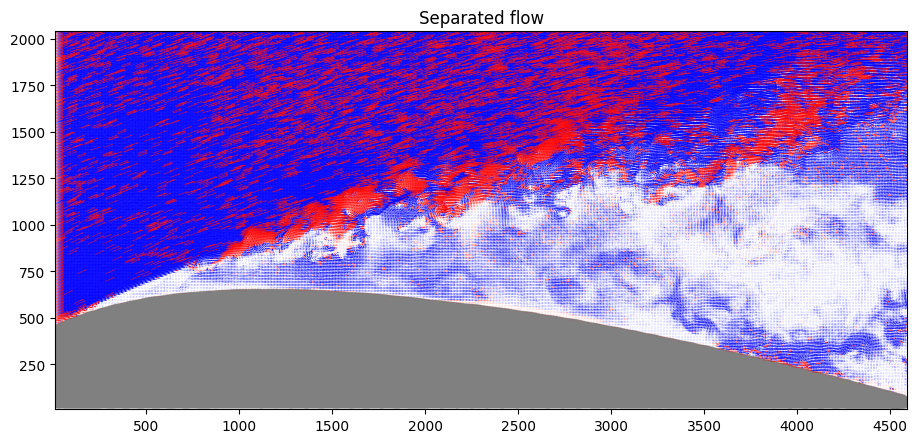

In [5]:
# Create a figure.
fig, ax = plt.subplots(figsize=(11, 11))
ax.set_aspect(1)
vector_width = 0.0005
vector_scale = 1000

# Modify tick labels and ticks.
tick_step = 250
ax.set_xticks(range(0, int(x[0, -1]), 2 * tick_step))
ax.set_yticks(range(0, int(y[0, -1]), tick_step))

# Adjust the axis limits to the minimum and maximum range.
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())

# Show the quiver plot.
ax.quiver(x[_loc], y[_loc], u[_loc], v[_loc], color="b", width=vector_width, scale=vector_scale)
ax.quiver(x[loc], y[loc], u[loc], v[loc], color="r", width=vector_width, scale=vector_scale)
ax.set_title(f"Separated flow")

# Show the mask on the plot.
ax.imshow(~mask, cmap='gray', alpha=0.5, extent=[x.min(), x.max(), y.min(), y.max()])
plt.show()



In [6]:
torch.cuda.empty_cache()